In [35]:
import pandas as pd
from Transformers import *
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Wczytanie danych

In [36]:
df=pd.read_csv("data/CleanedKaggle/financial_loan_cleaned.csv") 

Stworzenie Preprocessora z pliku *Transformers.py* i przetworzenie danych na zmienne numeryczne

In [37]:
preprocessor = getPipeline()
np_preprocessed = preprocessor.fit_transform(df)
np_preprocessed.shape

(38576, 33)

usuwamy basic_cat__loan_status_Fully Paid i ct_onehot__job__title_categorized_Other z uwagi na wysoką korelację z innymi zmiennymi, gdzie ta korelacja wynika ze wspólnego źródła danych (jakiegoś faktu) dla tych zmiennych

In [38]:
df_preprocessed = pd.DataFrame(np_preprocessed, columns=preprocessor.get_feature_names_out(df.columns.tolist()))
df_preprocessed.drop(columns=['basic_cat__loan_status_Fully Paid', 'ct_onehot__job__title_categorized_Other'], inplace=True)

In [39]:
X=df_preprocessed

In [40]:
X.head()

,ct_onehot__job__title_categorized_Education,ct_onehot__job__title_categorized_Energy/Utilities,ct_onehot__job__title_categorized_Finance,ct_onehot__job__title_categorized_Government/Civil Service,ct_onehot__job__title_categorized_Healthcare,ct_onehot__job__title_categorized_Legal/Law,ct_onehot__job__title_categorized_Manufacturing/Engineering,ct_onehot__job__title_categorized_Military,ct_onehot__job__title_categorized_Retail/Hospitality,ct_onehot__job__title_categorized_Self-Employed,...,basic_num__annual_income,basic_num__emp_years,basic_num__sub_grade_numeric,basic_cat__home_ownership_OTHER,basic_cat__home_ownership_OWN,basic_cat__home_ownership_RENT,basic_cat__loan_status_Current,basic_cat__verification_status_Source Verified,basic_cat__verification_status_Verified,basic_cat__term_months_60
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.616624,-1.396331,0.442734,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.336655,1.129782,1.471335,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305548,-0.273614,0.589677,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.429978,-1.396331,-0.585867,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.207729,1.410461,-1.467525,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Akceptowalny poziom korelacji zmiennych

<Axes: >

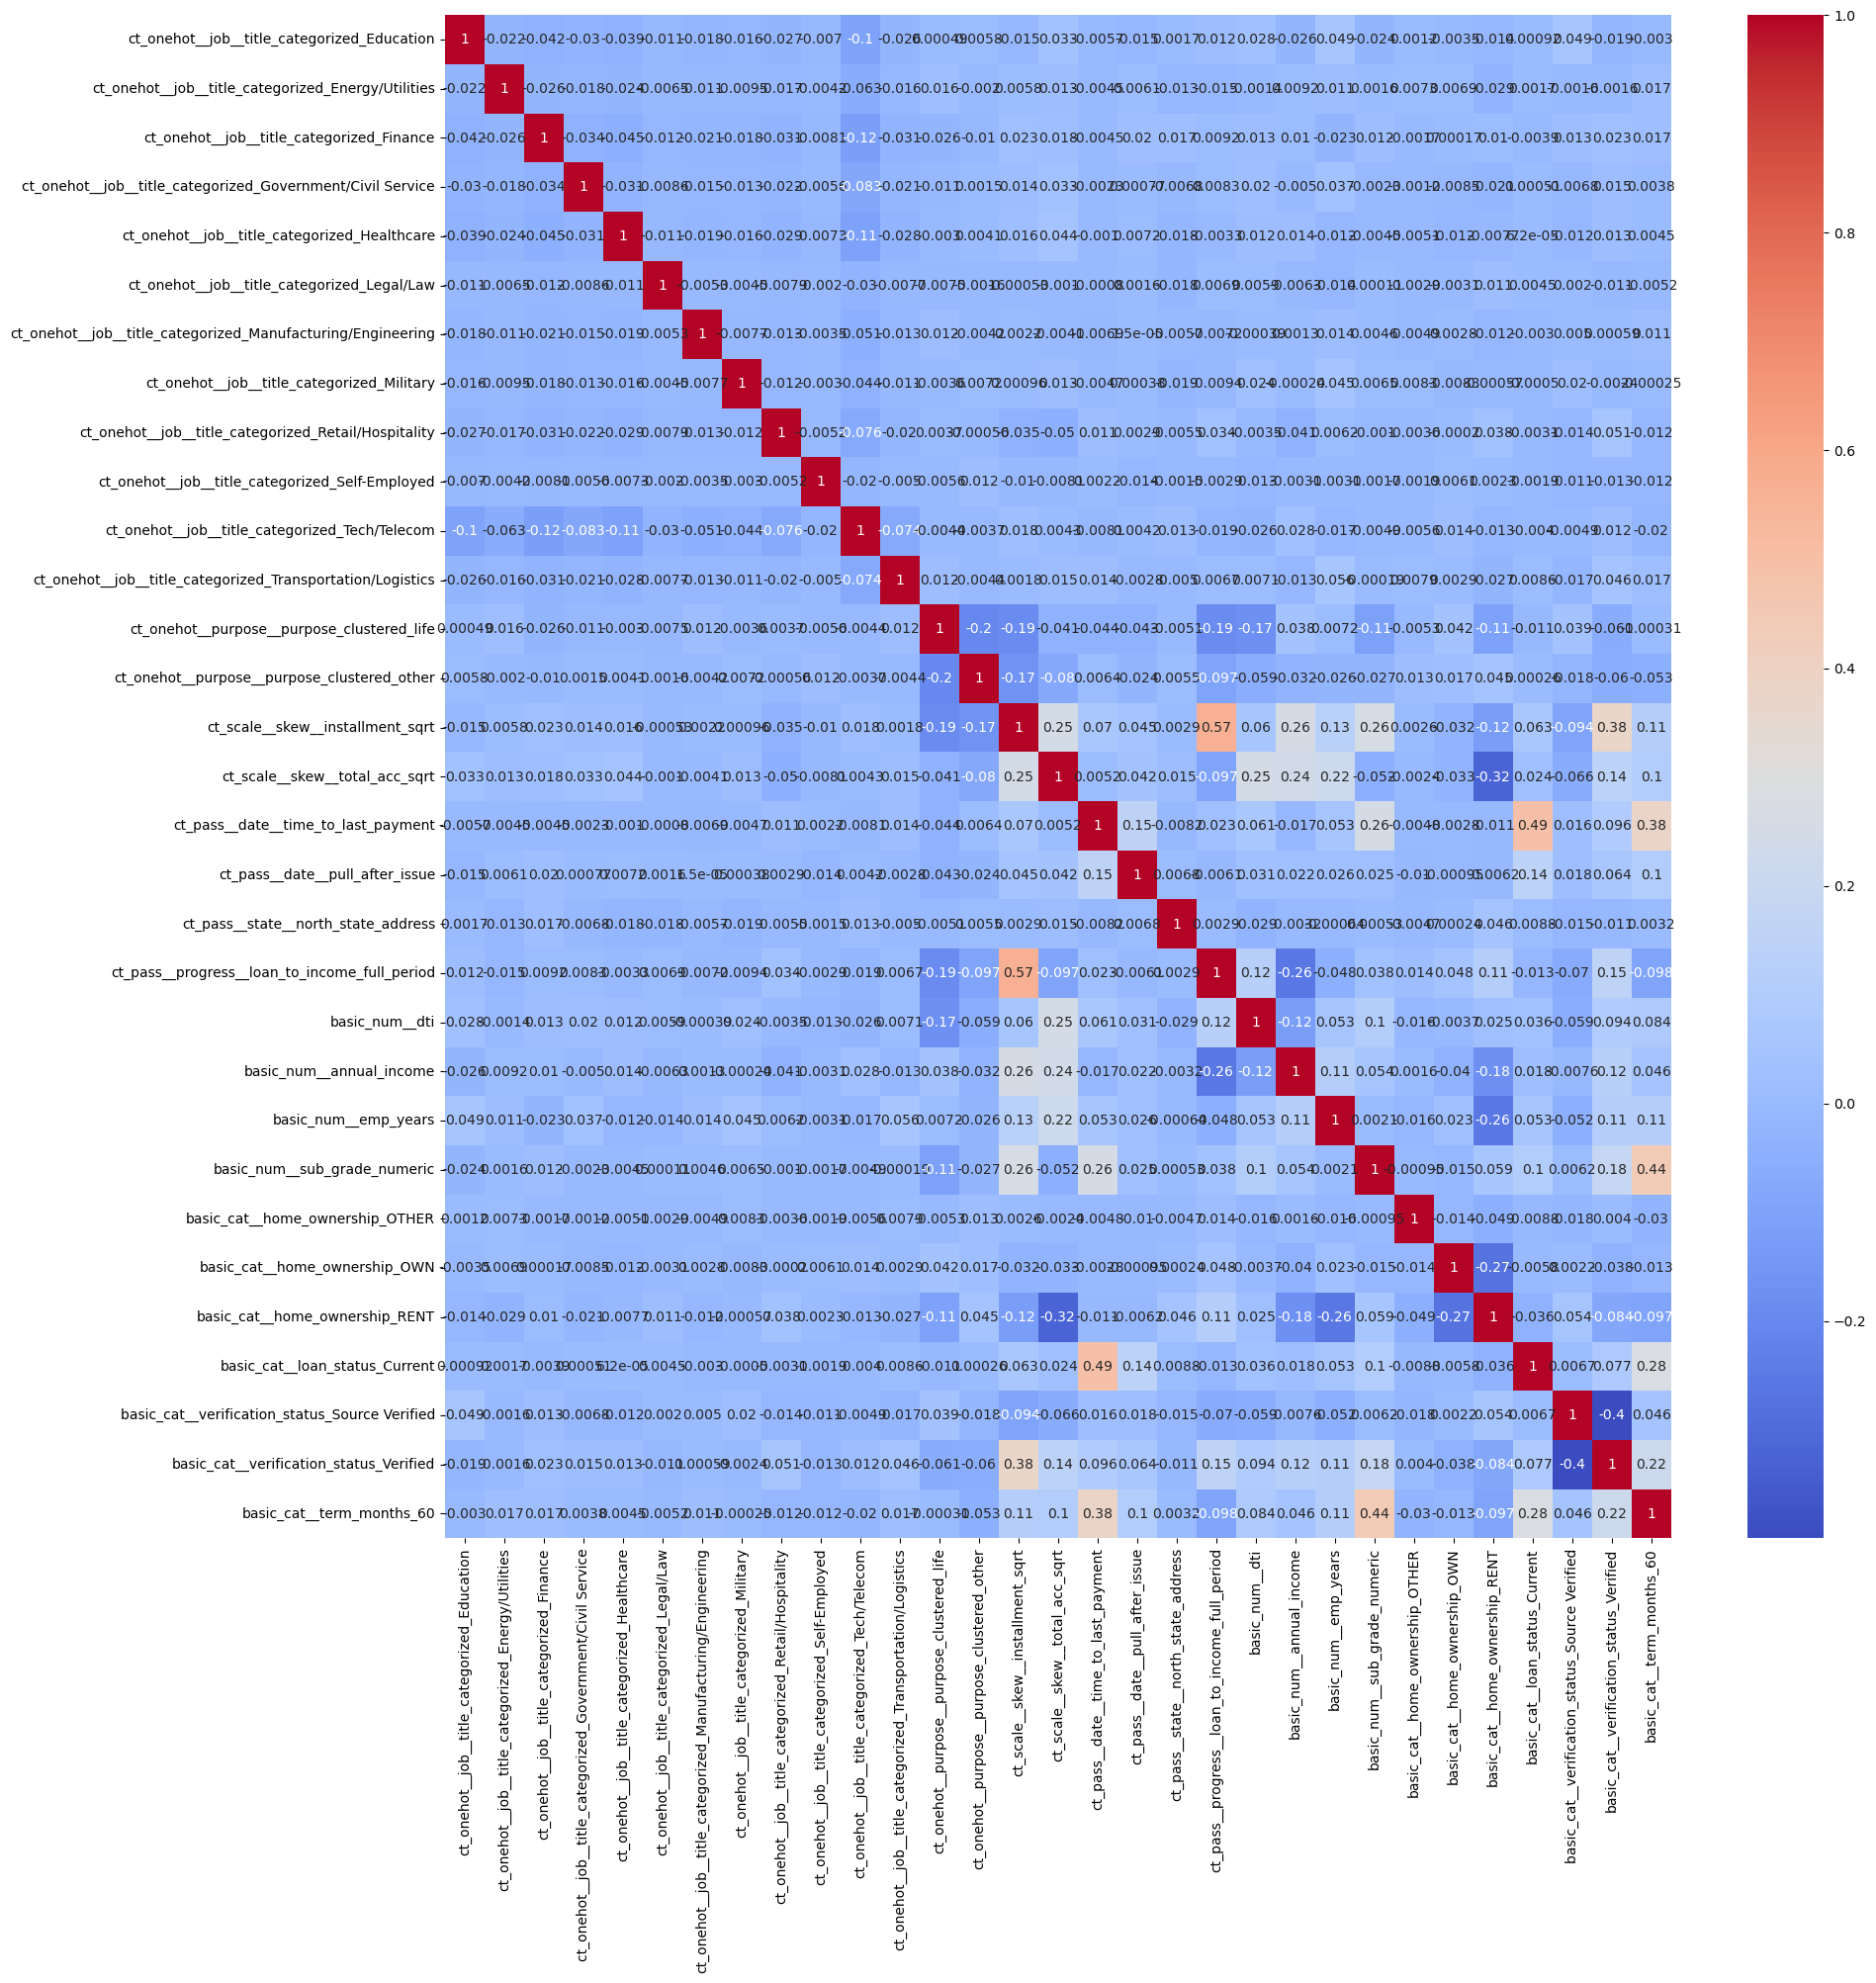

In [41]:
plt.figure(figsize=(20,20))
sns.heatmap(X.corr(), cmap='coolwarm', annot=True)

Koniecznie trzeba będzie znaleźć metrykę, która potrafi pracować na obu typach danych

In [58]:
bin = 0
for col in X.columns:
    if X[col].nunique() == 2:
        bin += 1
print(f'{bin} binary columns / {len(X.columns)} total columns')

23 binary columns / 31 total columns


Podział danych

In [42]:
X_train, X_val = train_test_split(X, test_size=0.3, random_state=42)

In [43]:
X_train, X_test = train_test_split(X_train, test_size=0.3, random_state=42)

In [44]:
X_train.shape, X_test.shape, X_val.shape

((18902, 31), (8101, 31), (11573, 31))

Zapis podzielonych danych

In [45]:
X_train.to_csv('data/TransformedData/train.csv', index=False)
X_val.to_csv('data/TransformedData/val.csv', index=False)
X_test.to_csv('data/TransformedData/test.csv', index=False)